# MiniTetris

>- **NAME: Amirhosein Rezaei**
>- **STUDENT ID: 401105989**

In this notebook the goal is to make the geometry of natural policy gradient visible in a Tetris-like control problem. The environment has many legal placements at each state, and the policy is a softmax over hand-designed afterstate features.

We will compare two update directions:

$$
d_{\mathrm{PG}} = g,
\qquad
d_{\mathrm{NPG}} = (F+\lambda I)^{-1}g,
$$

where $g$ estimates the policy gradient and $F$ estimates the Fisher information matrix of the policy.

The notebook therefore includes both training curves and geometric visualizations: KL-scaled updates, an empirical return landscape in the PG/NPG plane, and the greedy-action limit for the compatible function approximator.


In [35]:
import math
import time
import itertools
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt

try:
    from joblib import Parallel, delayed
    JOBLIB_AVAILABLE = True
except Exception:
    JOBLIB_AVAILABLE = False
    Parallel = None
    delayed = None

np.set_printoptions(precision=4, suppress=True)


In [36]:
# -----------------------------
# Global experiment knobs
# -----------------------------

HEIGHT = 10
WIDTH = 10
MAX_STEPS = 500

# batch size
BATCH_EPISODES = 100

# training iterations
N_ITER_PG_RAW = 600
N_ITER_NPG_RAW = 600
N_ITER_PG_KL = 600
N_ITER_NPG_KL = 600

# raw step sizes
ALPHA_PG_RAW = 0.5
ALPHA_NPG_RAW = 0.1

SEED = 7
rng = np.random.default_rng(SEED)

PARALLEL_ROLLOUTS = True
N_JOBS = -1

DAMPING = 0.01

# KL budget
TARGET_KL = 0.01

print(dict(
    HEIGHT=HEIGHT, WIDTH=WIDTH, MAX_STEPS=MAX_STEPS, BATCH_EPISODES=BATCH_EPISODES,
    N_ITER_PG_RAW=N_ITER_PG_RAW, N_ITER_NPG_RAW=N_ITER_NPG_RAW,
    N_ITER_PG_KL=N_ITER_PG_KL, N_ITER_NPG_KL=N_ITER_NPG_KL,
    ALPHA_PG_RAW=ALPHA_PG_RAW, ALPHA_NPG_RAW=ALPHA_NPG_RAW,
    DAMPING=DAMPING, TARGET_KL=TARGET_KL,
    PARALLEL_ROLLOUTS=PARALLEL_ROLLOUTS, N_JOBS=N_JOBS,
    JOBLIB_AVAILABLE=JOBLIB_AVAILABLE
))

{'HEIGHT': 10, 'WIDTH': 10, 'MAX_STEPS': 500, 'BATCH_EPISODES': 100, 'N_ITER_PG_RAW': 600, 'N_ITER_NPG_RAW': 600, 'N_ITER_PG_KL': 600, 'N_ITER_NPG_KL': 600, 'ALPHA_PG_RAW': 0.5, 'ALPHA_NPG_RAW': 0.1, 'DAMPING': 0.01, 'TARGET_KL': 0.01, 'PARALLEL_ROLLOUTS': True, 'N_JOBS': -1, 'JOBLIB_AVAILABLE': True}


## 1. A Tetris-like MDP

We implement a compact Tetris environment.

State:
- A binary board.
- A current piece.

Action:
- Choose one legal placement of the current piece.
- The piece is dropped vertically.
- Full rows are cleared.

Reward:
- The reward is the line-clearing score from the resulting board.

Policy:
- For every legal placement, compute an afterstate feature vector $\phi_{s,a}$.
- Use a softmax policy:
$$
\pi_\theta(a|s)
=
\frac{\exp(\theta^\top \phi_{s,a})}{\sum_b \exp(\theta^\top \phi_{s,b})}.
$$

This is the exponential-family form used in the theory.


In [37]:
# -----------------------------
# Tetromino definitions
# Coordinates are (row, col), normalized so min row = min col = 0.
# -----------------------------

RAW_PIECES = {
    "I": np.array([[0,0], [0,1], [0,2], [0,3]]),
    "O": np.array([[0,0], [0,1], [1,0], [1,1]]),
    "T": np.array([[0,1], [1,0], [1,1], [1,2]]),
    "S": np.array([[0,1], [0,2], [1,0], [1,1]]),
    "Z": np.array([[0,0], [0,1], [1,1], [1,2]]),
    "J": np.array([[0,0], [1,0], [1,1], [1,2]]),
    "L": np.array([[0,2], [1,0], [1,1], [1,2]]),
}

PIECE_NAMES = list(RAW_PIECES.keys())

def normalize_shape(coords: np.ndarray) -> np.ndarray:
    coords = coords.copy()
    coords[:,0] -= coords[:,0].min()
    coords[:,1] -= coords[:,1].min()
    # Sort for uniqueness
    coords = coords[np.lexsort((coords[:,1], coords[:,0]))]
    return coords

def rotate_shape(coords: np.ndarray) -> np.ndarray:
    # Rotate 90 degrees clockwise around origin, then normalize.
    r, c = coords[:,0], coords[:,1]
    rotated = np.stack([c, -r], axis=1)
    return normalize_shape(rotated)

def unique_rotations(coords: np.ndarray) -> List[np.ndarray]:
    rots = []
    seen = set()
    cur = normalize_shape(coords)
    for _ in range(4):
        key = tuple(map(tuple, cur.tolist()))
        if key not in seen:
            seen.add(key)
            rots.append(cur)
        cur = rotate_shape(cur)
    return rots

PIECES = [unique_rotations(RAW_PIECES[name]) for name in PIECE_NAMES]

for name, rots in zip(PIECE_NAMES, PIECES):
    print(name, "rotations:", len(rots))


I rotations: 2
O rotations: 1
T rotations: 4
S rotations: 2
Z rotations: 2
J rotations: 4
L rotations: 4


legal T placements on empty board: 34


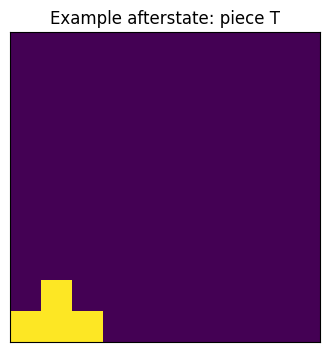

In [38]:
# -----------------------------
# Board mechanics
# -----------------------------

def empty_board(height=HEIGHT, width=WIDTH) -> np.ndarray:
    return np.zeros((height, width), dtype=np.int8)

def shape_height(shape):
    return int(shape[:,0].max() + 1)

def shape_width(shape):
    return int(shape[:,1].max() + 1)

def can_place(board: np.ndarray, shape: np.ndarray, y: int, x: int) -> bool:
    H, W = board.shape
    for dy, dx in shape:
        r, c = y + int(dy), x + int(dx)
        if r < 0 or r >= H or c < 0 or c >= W:
            return False
        if board[r, c]:
            return False
    return True

def drop_y(board: np.ndarray, shape: np.ndarray, x: int) -> Optional[int]:
    # In this simplified version, the entire shape must be placeable at row 0.
    if not can_place(board, shape, 0, x):
        return None
    y = 0
    while can_place(board, shape, y + 1, x):
        y += 1
    return y

def place_and_clear(board: np.ndarray, shape: np.ndarray, y: int, x: int):
    H, W = board.shape
    b = board.copy()
    placed = []
    for dy, dx in shape:
        r, c = y + int(dy), x + int(dx)
        b[r, c] = 1
        placed.append((r, c))
    full_rows = np.where(b.sum(axis=1) == W)[0]
    lines = len(full_rows)
    eroded_piece_cells = sum(1 for (r, c) in placed if r in set(full_rows.tolist()))
    if lines > 0:
        keep = np.array([r for r in range(H) if r not in set(full_rows.tolist())], dtype=int)
        new_rows = b[keep, :]
        cleared = np.zeros((lines, W), dtype=np.int8)
        b = np.vstack([cleared, new_rows])
    return b, lines, eroded_piece_cells

def legal_afterstates(board: np.ndarray, piece_id: int):
    actions = []
    for rot_id, shape in enumerate(PIECES[piece_id]):
        for x in range(board.shape[1] - shape_width(shape) + 1):
            y = drop_y(board, shape, x)
            if y is None:
                continue
            new_board, lines, eroded = place_and_clear(board, shape, y, x)
            landing_height = board.shape[0] - (y + 0.5 * shape_height(shape))
            actions.append(dict(
                piece_id=piece_id,
                rot_id=rot_id,
                x=x,
                y=y,
                board=new_board,
                lines=lines,
                eroded_piece_cells=eroded,
                landing_height=landing_height,
            ))
    return actions

def render_board(board, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 6))
    ax.imshow(board, interpolation="nearest", origin="upper")
    ax.set_xticks([])
    ax.set_yticks([])
    if title:
        ax.set_title(title)
    return ax

# quick sanity check
b = empty_board()
pid = PIECE_NAMES.index("T")
actions = legal_afterstates(b, pid)
print("legal T placements on empty board:", len(actions))
render_board(actions[0]["board"], title=f"Example afterstate: piece {PIECE_NAMES[pid]}")
plt.show()


## 2. Afterstate features

In this Tetris experiment we use hand-designed board features. For each legal placement, we compute features of the resulting afterstate board.

For each afterstate we compute:
- aggregate height,
- max/min/std height,
- bumpiness,
- holes,
- weighted holes,
- wells,
- row transitions,
- column transitions,
- filled fraction,
- landing height,
- eroded piece cells,
- piece identity.

The feature vector for a state-action pair is simply

$$
\phi(s,a)=x(s,a),
$$

where $x(s,a)$ is the vector of normalized afterstate features. There is no additional feature lifting. The policy remains in the exponential-family form because it is still linear in the parameters inside the softmax logits:

$$
\pi_\theta(a|s)
\propto
\exp(\theta^\top \phi(s,a)).
$$


In [39]:
# -----------------------------
# Board feature functions
# -----------------------------

def column_heights(board: np.ndarray) -> np.ndarray:
    H, W = board.shape
    heights = np.zeros(W, dtype=float)
    for c in range(W):
        filled = np.where(board[:, c] > 0)[0]
        heights[c] = 0 if len(filled) == 0 else H - filled[0]
    return heights

def count_holes_and_weighted(board: np.ndarray):
    H, W = board.shape
    holes = 0
    weighted = 0
    for c in range(W):
        filled_seen = False
        blocks_above = 0
        for r in range(H):
            if board[r, c]:
                filled_seen = True
                blocks_above += 1
            elif filled_seen:
                holes += 1
                weighted += blocks_above
    return holes, weighted

def well_sum(board: np.ndarray):
    H, W = board.shape
    total = 0
    for c in range(W):
        depth = 0
        for r in range(H):
            left_filled = (c == 0) or bool(board[r, c-1])
            right_filled = (c == W-1) or bool(board[r, c+1])
            if (not board[r, c]) and left_filled and right_filled:
                depth += 1
                total += depth
            else:
                depth = 0
    return total

def row_transitions(board: np.ndarray):
    H, W = board.shape
    trans = 0
    for r in range(H):
        prev = 1  # wall
        for c in range(W):
            cur = int(board[r, c])
            trans += (cur != prev)
            prev = cur
        trans += (prev != 1)  # right wall
    return trans

def col_transitions(board: np.ndarray):
    H, W = board.shape
    trans = 0
    for c in range(W):
        prev = 1  # ceiling as filled boundary
        for r in range(H):
            cur = int(board[r, c])
            trans += (cur != prev)
            prev = cur
        trans += (prev != 1)  # floor as filled boundary
    return trans

def base_features(after_board, lines, landing_height, eroded_piece_cells, piece_id):
    H, W = after_board.shape
    heights = column_heights(after_board)
    holes, weighted_holes = count_holes_and_weighted(after_board)
    wells = well_sum(after_board)
    bumpiness = np.abs(np.diff(heights)).sum() if W > 1 else 0.0
    filled = after_board.sum()
    max_h = heights.max()
    min_h = heights.min()
    std_h = heights.std()

    # Normalize features so the logits and Fisher estimates are numerically stable.
    continuous = np.array([
        lines / 4.0,
        heights.sum() / (H * W),
        max_h / H,
        min_h / H,
        std_h / H,
        bumpiness / (H * max(W-1, 1)),
        holes / (H * W),
        weighted_holes / (H * W),
        wells / (H * W),
        row_transitions(after_board) / (H * (W + 1)),
        col_transitions(after_board) / (W * (H + 1)),
        filled / (H * W),
        landing_height / H,
        eroded_piece_cells / 4.0,
        (max_h - min_h) / H,
    ], dtype=float)

    piece_onehot = np.zeros(len(PIECE_NAMES), dtype=float)
    piece_onehot[piece_id] = 1.0
    return np.concatenate([continuous, piece_onehot])

BASE_DIM = 15 + len(PIECE_NAMES)
FEATURE_DIM = BASE_DIM
print("FEATURE_DIM:", FEATURE_DIM)

def attach_features(actions):
    for a in actions:
        phi = base_features(a["board"], a["lines"], a["landing_height"], a["eroded_piece_cells"], a["piece_id"])
        a["base_phi"] = phi
        a["phi"] = phi
    return actions

# sanity check
b = empty_board()
acts = attach_features(legal_afterstates(b, 0))
print("actions:", len(acts), "feature shape:", acts[0]["phi"].shape)


FEATURE_DIM: 22
actions: 17 feature shape: (22,)


## 3. Softmax policy, score features, and the Fisher matrix

For legal actions $a\in\mathcal{A}(s)$, the policy is

$$
\pi_\theta(a|s)=
\frac{\exp(\theta^\top\phi_{s,a})}
{\sum_b \exp(\theta^\top\phi_{s,b})}.
$$

For this policy,

$$
\nabla_\theta \log \pi_\theta(a|s)
=
\phi_{s,a}
-
\mathbb{E}_{b\sim \pi_\theta(\cdot|s)}[\phi_{s,b}].
$$

This is the score feature.  
It is also exactly the feature used by the compatible function approximator.


In [50]:
def softmax(logits: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    # stable softmax
    logits = logits / temperature
    max_logit = np.max(logits)
    exp_logits = np.exp(logits - max_logit)
    return exp_logits / np.sum(exp_logits)


def policy_distribution(theta: np.ndarray, phis: np.ndarray, temperature: float = 1.0):
    # softmax policy distribution
    logits = phis @ theta
    # return softmax(logits, temperature)
    probs = softmax(logits, temperature)
    expected_phi = probs @ phis
    return probs, expected_phi, logits


def sample_policy_action(theta: np.ndarray, actions: List[dict], rng, temperature: float = 1.0):
    # sample action and score feature
    phis = np.array([a["phi"] for a in actions])
    logits = phis @ theta
    probs = softmax(logits, temperature)
    idx = rng.choice(len(actions), p=probs)
    expected_phi = probs @ phis
    score = phis[idx] - expected_phi
    return idx, probs[idx], score, phis[idx], logits


def tetris_reward(lines: int):
    # line-clearing score
    if lines == 0:
        return 0
    elif lines == 1:
        return 40
    elif lines == 2:
        return 100
    elif lines == 3:
        return 300
    elif lines == 4:
        return 800
    else:
        return 0

## 4. Rollouts and estimates of $g$ and $F$

For a batch of trajectories, we estimate

$$
g
=
\mathbb{E}[\nabla \log \pi_\theta(a_t|s_t)\,\widehat Q_t],
$$

and

$$
F
=
\mathbb{E}[\nabla \log \pi_\theta(a_t|s_t)\nabla \log \pi_\theta(a_t|s_t)^\top].
$$

We use centered returns:
$$
\widehat Q_t
=
\sum_{k=t}^{T-1} (r_k-\hat \eta).
$$

This is a finite-trajectory analogue of the average-reward differential return.


In [51]:
@dataclass
class Episode:
    rewards: List[float]
    scores: List[np.ndarray]
    length: int
    lines: int
    final_board: np.ndarray
    states_for_viz: List[dict]

def simulate_episode(theta: np.ndarray, rng, max_steps=MAX_STEPS, temperature=1.0,
                     keep_states_for_viz=False) -> Episode:
    board = empty_board()
    rewards = []
    scores = []
    total_lines = 0
    states_for_viz = []

    for t in range(max_steps):
        piece_id = int(rng.integers(len(PIECE_NAMES)))
        actions = attach_features(legal_afterstates(board, piece_id))
        if len(actions) == 0:
            break

        if keep_states_for_viz and len(states_for_viz) < 10:
            states_for_viz.append(dict(board=board.copy(), piece_id=piece_id, actions=actions))

        # policy action
        idx, prob, score, phi, logits = sample_policy_action(theta, actions, rng, temperature)

        chosen = actions[idx]
        board = chosen["board"]
        r = tetris_reward(chosen["lines"])

        rewards.append(float(r))
        scores.append(score)
        total_lines += chosen["lines"]

    return Episode(rewards=rewards, scores=scores, length=len(rewards), lines=total_lines,
                   final_board=board, states_for_viz=states_for_viz)

def _simulate_episode_from_seed(theta: np.ndarray, seed: int, max_steps=MAX_STEPS,
                                temperature=1.0, keep_states_for_viz=False) -> Episode:
    local_rng = np.random.default_rng(int(seed))
    return simulate_episode(theta, local_rng, max_steps=max_steps, temperature=temperature,
                            keep_states_for_viz=keep_states_for_viz)

def collect_episodes(theta: np.ndarray, rng, batch_episodes=BATCH_EPISODES, max_steps=MAX_STEPS,
                     temperature=1.0, keep_first_for_viz=True,
                     parallel_rollouts=PARALLEL_ROLLOUTS, n_jobs=N_JOBS):
    # episode seeds
    seeds = rng.integers(0, 2**31, batch_episodes)

    episodes = []
    start_idx = 0

    if keep_first_for_viz and batch_episodes > 0:
        episodes.append(_simulate_episode_from_seed(theta, int(seeds[0]), max_steps=max_steps,
                                                    temperature=temperature,
                                                    keep_states_for_viz=True))
        start_idx = 1

    remaining = [int(s) for s in seeds[start_idx:]]

    use_parallel = (
        parallel_rollouts
        and JOBLIB_AVAILABLE
        and n_jobs != 1
        and len(remaining) > 1
    )

    if use_parallel:
        new_eps = Parallel(n_jobs=n_jobs, prefer="processes")(
            delayed(_simulate_episode_from_seed)(
                theta,
                seed,
                max_steps=max_steps,
                temperature=temperature,
                keep_states_for_viz=False,
            )
            for seed in remaining
        )
    else:
        new_eps = [
            _simulate_episode_from_seed(theta, seed, max_steps=max_steps,
                                        temperature=temperature,
                                        keep_states_for_viz=False)
            for seed in remaining
        ]

    episodes.extend(new_eps)
    return episodes

def centered_returns(rewards, eta_hat, trace_decay=1.0):
    # centered returns
    T = len(rewards)
    G = np.zeros(T)
    out = None
    running = 0.0
    for t in reversed(range(T)):
        running = (rewards[t] - eta_hat) + trace_decay * running
        G[t] = running
    return G

def estimate_batch(theta: np.ndarray, rng, batch_episodes=BATCH_EPISODES, max_steps=MAX_STEPS,
                   trace_decay=1.0, temperature=1.0,
                   parallel_rollouts=PARALLEL_ROLLOUTS, n_jobs=N_JOBS):
    episodes = collect_episodes(theta, rng, batch_episodes=batch_episodes, max_steps=max_steps,
                                temperature=temperature, keep_first_for_viz=True,
                                parallel_rollouts=parallel_rollouts, n_jobs=n_jobs)

    # eta estimate
    all_rewards = []
    for ep in episodes:
        all_rewards.extend(ep.rewards)
    
    if len(all_rewards) == 0:
        raise RuntimeError("All episodes terminated immediately. Try smaller initial theta or smaller board height.")

    eta_hat = np.mean(all_rewards)

    score_list = []
    weighted_scores = []
    returns_list = []

    # centered returns and weighted scores
    for ep in episodes:
        Gs = centered_returns(ep.rewards, eta_hat, trace_decay)
        for score, G in zip(ep.scores, Gs):
            score_list.append(score)
            weighted_scores.append(score * G)
            returns_list.append(G)

    # g and F
    S = np.array(score_list) 
    WG = np.array(weighted_scores)
    g = np.mean(WG, axis=0)
    F = np.mean([np.outer(s, s) for s in S], axis=0)

    info = dict(
        eta_hat=eta_hat,
        mean_episode_return=float(np.mean([sum(ep.rewards) for ep in episodes])),
        mean_length=float(np.mean([ep.length for ep in episodes])),
        mean_lines=float(np.mean([ep.lines for ep in episodes])),
        n_steps=int(S.shape[0]),
        n_episodes=len(episodes),
        episodes=episodes,
        returns=np.array(returns_list),
        scores=S,
    )
    return g, F, info

# Sanity check one batch
theta0 = np.zeros(FEATURE_DIM)
g0, F0, info0 = estimate_batch(theta0, rng, batch_episodes=3, max_steps=50, n_jobs=1)
print("g norm:", np.linalg.norm(g0))
print("F shape:", F0.shape, "F trace:", np.trace(F0))
print("eta_hat:", info0["eta_hat"], "mean length:", info0["mean_length"], "mean lines:", info0["mean_lines"])

g norm: 0.0
F shape: (22, 22) F trace: 0.055125350026299424
eta_hat: 0.0 mean length: 14.666666666666666 mean lines: 0.0


## 5. Natural gradient solve

We compute

$$
d_{\text{NPG}}
=
(F+\lambda I)^{-1}g.
$$

For larger feature spaces this is often solved with conjugate gradient.  
Here we include both direct solve and conjugate gradient.

The update is scaled so that

$$
\frac{1}{2}\Delta\theta^\top F\Delta\theta
\approx
\texttt{TARGET\_KL}.
$$

This makes vanilla PG and NPG comparable as **directions under the same local policy-distribution step size**.


In [52]:
def conjugate_gradient(A_fn, b, max_iter=50, tol=1e-10):
    # conjugate gradient
    x = np.zeros_like(b)
    r = b - A_fn(x)
    p = r.copy()
    rs_old = np.dot(r, r)
    
    for i in range(max_iter):
        Ap = A_fn(p)
        alpha = rs_old / np.dot(p, Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rs_new = np.dot(r, r)
        if np.sqrt(rs_new) < tol:
            break
        beta = rs_new / rs_old
        p = r + beta * p
        rs_old = rs_new
    
    return x


def natural_direction(F, g, damping=DAMPING, use_cg=False):
    F_damped = F + damping * np.eye(F.shape[0])

    if use_cg:
        def A_fn(x):
            return F_damped @ x
        d = conjugate_gradient(A_fn, g)
    else:
        d = np.linalg.solve(F_damped, g)
    
    return d


def fisher_scaled_update(direction, F, target_kl=TARGET_KL):
    # Fisher/KL scaling
    kl = 0.5 * direction @ F @ direction
    if kl > 1e-10:
        scale = np.sqrt(target_kl / kl)
    else:
        scale = 1.0
    return direction * scale


def train(method: str, seed: int, n_iter=None, batch_episodes=BATCH_EPISODES,
          max_steps=MAX_STEPS, damping=DAMPING, target_kl=TARGET_KL,
          trace_decay=1.0, use_cg=False,
          use_target_kl=True, alpha_pg=ALPHA_PG_RAW, alpha_npg=ALPHA_NPG_RAW,
          parallel_rollouts=PARALLEL_ROLLOUTS, n_jobs=N_JOBS):

    assert method in ["pg", "npg"]

    if n_iter is None:
        n_iter = N_ITER_PG_KL if method == "pg" else N_ITER_NPG_KL

    local_rng = np.random.default_rng(seed)
    theta = np.zeros(FEATURE_DIM)
    hist = []

    start = time.time()

    for it in range(n_iter):
        g, F, info = estimate_batch(
            theta,
            local_rng,
            batch_episodes=batch_episodes,
            max_steps=max_steps,
            trace_decay=trace_decay,
            parallel_rollouts=parallel_rollouts,
            n_jobs=n_jobs,
        )

        # choose PG or NPG direction
        if method == "pg":
            direction = g.copy()
            update_rule = "pg"
        else:  # npg
            direction = natural_direction(F, g, damping=damping, use_cg=use_cg)
            update_rule = "npg"

        # fixed-alpha or KL-scaled update
        if use_target_kl:
            delta = fisher_scaled_update(direction, F, target_kl=target_kl)
            alpha_used = None
        else:
            alpha = alpha_pg if method == "pg" else alpha_npg
            delta = alpha * direction
            alpha_used = alpha

        theta = theta + delta

        hist.append(dict(
            iter=it,
            eta_hat=info["eta_hat"],
            mean_episode_return=info["mean_episode_return"],
            mean_length=info["mean_length"],
            mean_lines=info["mean_lines"],
            n_steps=info["n_steps"],
            n_episodes=info.get("n_episodes", batch_episodes),
            grad_norm=float(np.linalg.norm(g)),
            dir_norm=float(np.linalg.norm(direction)),
            theta_norm=float(np.linalg.norm(theta)),
            update_rule=update_rule,
            alpha=alpha_used,
            elapsed=time.time() - start,
        ))

        if it % max(1, n_iter // 10) == 0 or it == n_iter - 1:
            if use_target_kl:
                step_desc = f"target-KL {target_kl:.3g}"
            else:
                step_desc = f"alpha {alpha:.3g}"

            print(
                f"{method.upper():>3} iter {it:03d} | "
                f"eta {info['eta_hat']:+.4f} | "
                f"len {info['mean_length']:.1f} | "
                f"lines {info['mean_lines']:.2f} | "
                f"steps {info['n_steps']} | {step_desc}"
            )

    return theta, hist

## 6. Two comparisons: fixed learning rate vs KL-scaled updates

We will run two versions of the PG/NPG comparison.

### 6.1 Fixed learning-rate updates

First, we disable target-KL scaling. The updates are simply

$$
\theta \leftarrow \theta + \alpha d,
$$

where

$$
d_{\mathrm{PG}} = g,
\qquad
d_{\mathrm{NPG}} = (F+\lambda I)^{-1}g.
$$

This is closer to the naive optimization comparison: PG and NPG use their own directions, but the update size is controlled by a fixed scalar learning rate.

### 6.2 KL-scaled updates

Then we run the more geometric comparison. Both PG and NPG directions are scaled so that

$$
\frac{1}{2}\Delta\theta^\top F\Delta\theta
\approx
\texttt{TARGET\_KL}.
$$

This makes the comparison about the direction itself, because both updates are given approximately the same local policy-distribution movement.

In both cases, the only difference between PG and NPG is the direction:

$$
d_{\mathrm{PG}} = g,
\qquad
d_{\mathrm{NPG}}=(F+\lambda I)^{-1}g.
$$

In [33]:
# -----------------------------
# 6.1 Fixed learning-rate comparison: no target-KL scaling
# -----------------------------

theta_pg_raw, hist_pg_raw = train(
    "pg",
    seed=2,
    n_iter=N_ITER_PG_RAW,
    use_target_kl=False,
    alpha_pg=ALPHA_PG_RAW,
    alpha_npg=ALPHA_NPG_RAW,
)

theta_npg_raw, hist_npg_raw = train(
    "npg",
    seed=2,
    n_iter=N_ITER_NPG_RAW,
    use_target_kl=False,
    alpha_pg=ALPHA_PG_RAW,
    alpha_npg=ALPHA_NPG_RAW,
)


 PG iter 000 | eta +0.3326 | len 14.4 | lines 0.12 | steps 1443 | alpha 0.5
 PG iter 060 | eta +0.2846 | len 15.5 | lines 0.11 | steps 1546 | alpha 0.5
 PG iter 120 | eta +2.0704 | len 19.9 | lines 1.03 | steps 1990 | alpha 0.5
 PG iter 180 | eta +4.6772 | len 25.9 | lines 2.98 | steps 2587 | alpha 0.5
 PG iter 240 | eta +6.0186 | len 30.0 | lines 4.43 | steps 3004 | alpha 0.5
 PG iter 300 | eta +6.4664 | len 31.9 | lines 5.13 | steps 3195 | alpha 0.5
 PG iter 360 | eta +7.1457 | len 34.6 | lines 6.13 | steps 3465 | alpha 0.5
 PG iter 420 | eta +7.9927 | len 38.4 | lines 7.57 | steps 3841 | alpha 0.5
 PG iter 480 | eta +8.5239 | len 40.9 | lines 8.52 | steps 4085 | alpha 0.5
 PG iter 540 | eta +8.7776 | len 41.7 | lines 8.82 | steps 4172 | alpha 0.5
 PG iter 599 | eta +8.6608 | len 41.2 | lines 8.67 | steps 4122 | alpha 0.5
NPG iter 000 | eta +0.3326 | len 14.4 | lines 0.12 | steps 1443 | alpha 0.1
NPG iter 060 | eta +10.7394 | len 56.8 | lines 14.65 | steps 5680 | alpha 0.1
NPG iter 1

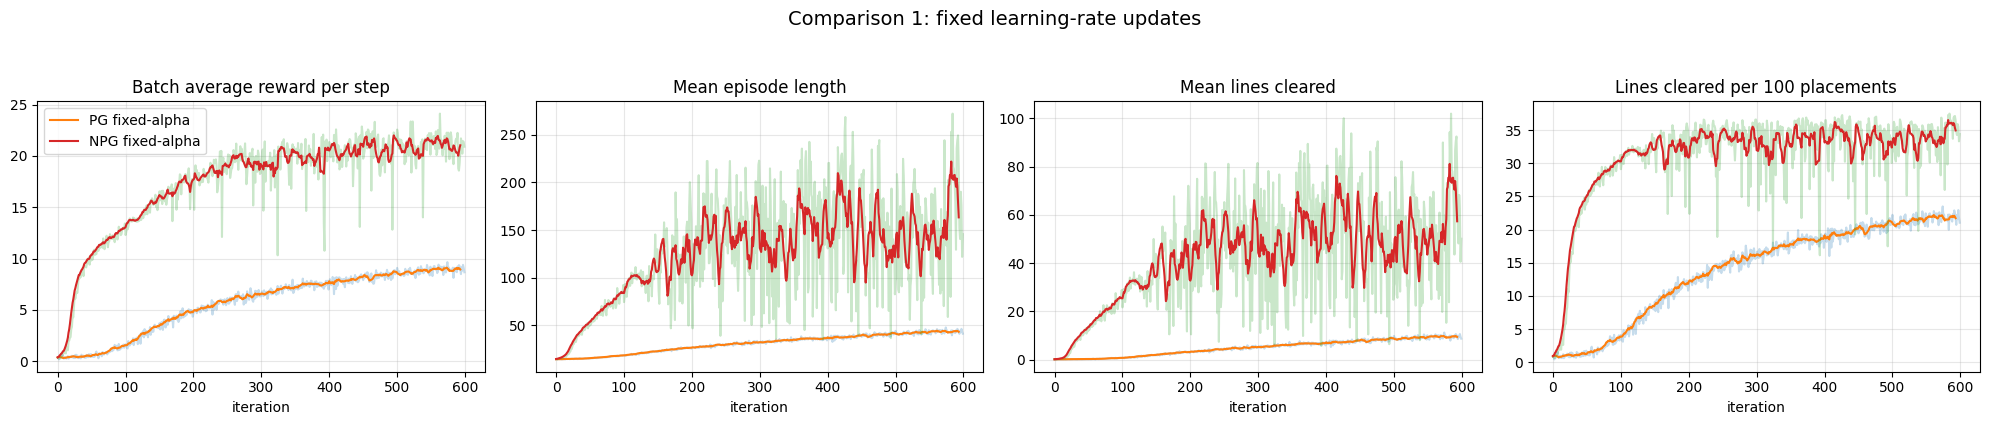

In [34]:
def moving_average(x, k=7):
    x = np.asarray(x, dtype=float)
    if len(x) < k:
        return x
    return np.convolve(x, np.ones(k)/k, mode="valid")

def add_derived_metrics(hist):
    out = []
    for h in hist:
        h = dict(h)
        h["lines_per_step"] = h["mean_lines"] / max(h["mean_length"], 1e-8)
        h["lines_per_100_steps"] = 100.0 * h["lines_per_step"]
        h["score_per_100_steps"] = 100.0 * h["eta_hat"]
        out.append(h)
    return out

def plot_training(histories, labels, title=None):
    histories = [add_derived_metrics(h) for h in histories]

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    metrics = ["eta_hat", "mean_length", "mean_lines", "lines_per_100_steps"]
    titles = [
        "Batch average reward per step",
        "Mean episode length",
        "Mean lines cleared",
        "Lines cleared per 100 placements",
    ]

    for ax, metric, ax_title in zip(axes, metrics, titles):
        for hist, label in zip(histories, labels):
            y = [h[metric] for h in hist]
            ax.plot(y, alpha=0.25)
            ma = moving_average(y, k=7)
            ax.plot(range(len(ma)), ma, label=label)
        ax.set_title(ax_title)
        ax.set_xlabel("iteration")
        ax.grid(True, alpha=0.3)

    axes[0].legend()
    if title is not None:
        fig.suptitle(title, y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_training(
    [hist_pg_raw, hist_npg_raw],
    ["PG fixed-alpha", "NPG fixed-alpha"],
    title="Comparison 1: fixed learning-rate updates",
)

 PG iter 000 | eta +0.3326 | len 14.4 | lines 0.12 | steps 1443 | target-KL 0.01
 PG iter 060 | eta +15.1145 | len 127.9 | lines 43.00 | steps 12793 | target-KL 0.01
 PG iter 120 | eta +17.4254 | len 98.6 | lines 31.16 | steps 9858 | target-KL 0.01
 PG iter 180 | eta +18.4964 | len 104.5 | lines 33.60 | steps 10455 | target-KL 0.01
 PG iter 240 | eta +18.8004 | len 124.5 | lines 41.54 | steps 12454 | target-KL 0.01
 PG iter 300 | eta +19.4651 | len 149.9 | lines 51.74 | steps 14993 | target-KL 0.01
 PG iter 360 | eta +20.2168 | len 130.1 | lines 43.89 | steps 13007 | target-KL 0.01
 PG iter 420 | eta +21.3354 | len 103.6 | lines 33.23 | steps 10364 | target-KL 0.01
 PG iter 480 | eta +20.6056 | len 134.1 | lines 45.55 | steps 13409 | target-KL 0.01
 PG iter 540 | eta +20.0700 | len 80.0 | lines 23.76 | steps 7997 | target-KL 0.01
 PG iter 599 | eta +20.2273 | len 155.7 | lines 54.08 | steps 15573 | target-KL 0.01
NPG iter 000 | eta +0.3326 | len 14.4 | lines 0.12 | steps 1443 | target-

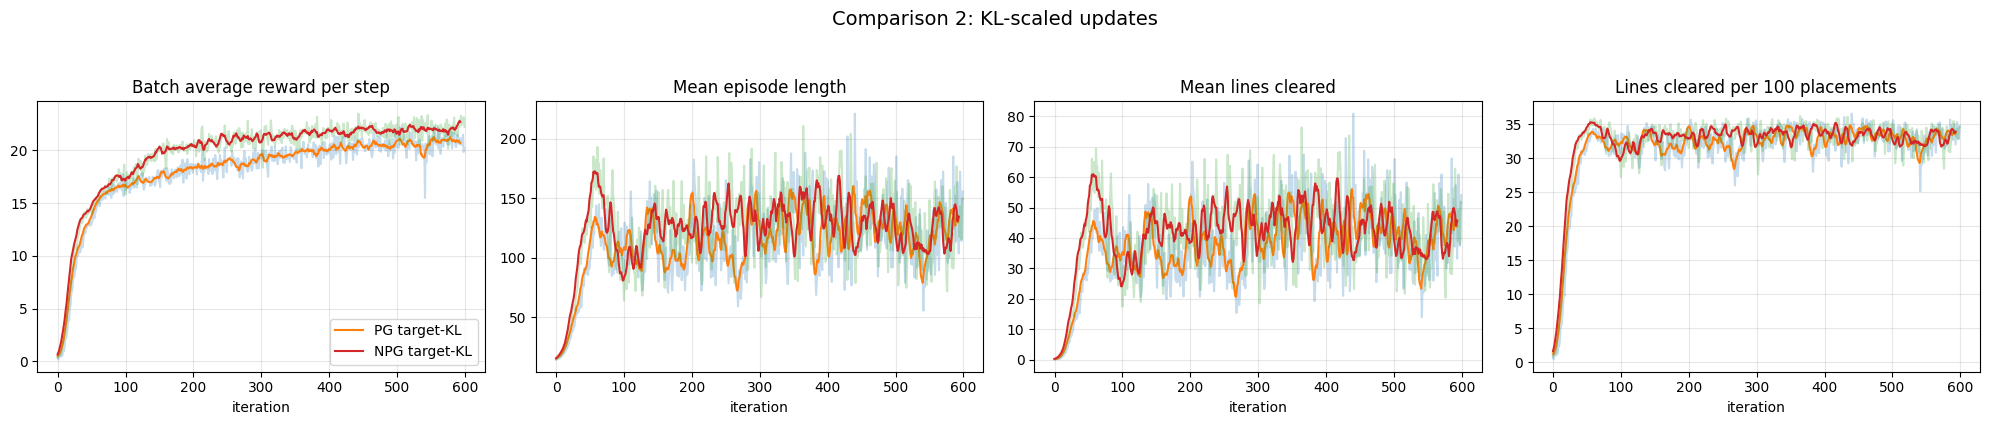

In [44]:
# -----------------------------
# 6.2 KL-scaled comparison: both methods get the same local policy-distribution step
# -----------------------------

theta_pg_kl, hist_pg_kl = train(
    "pg",
    seed=2,
    n_iter=N_ITER_PG_KL,
    use_target_kl=True,
    target_kl=TARGET_KL,
)

theta_npg_kl, hist_npg_kl = train(
    "npg",
    seed=2,
    n_iter=N_ITER_NPG_KL,
    use_target_kl=True,
    target_kl=TARGET_KL,
)

plot_training(
    [hist_pg_kl, hist_npg_kl],
    ["PG target-KL", "NPG target-KL"],
    title="Comparison 2: KL-scaled updates",
)

# Default aliases used in later sections.
# The greedy-limit visualization uses the KL-scaled NPG policy by default.
theta_pg, hist_pg = theta_pg_kl, hist_pg_kl
theta_npg, hist_npg = theta_npg_kl, hist_npg_kl


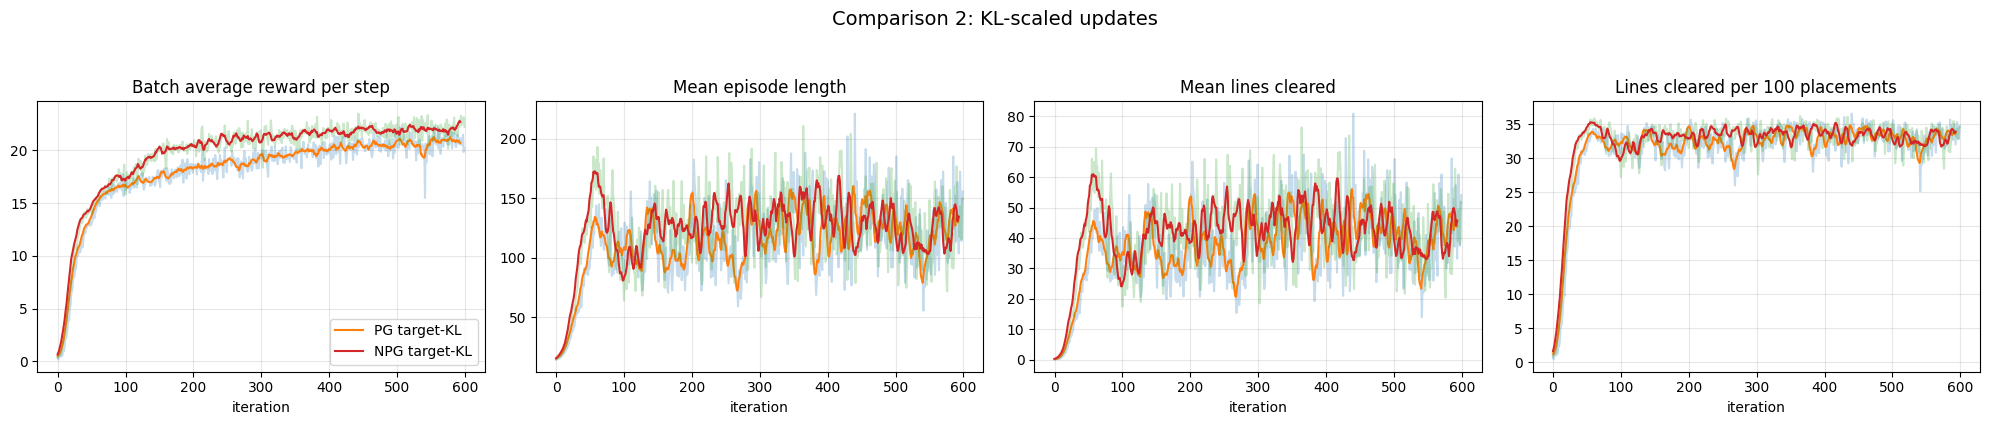

In [45]:
plot_training(
    [hist_pg_kl, hist_npg_kl],
    ["PG target-KL", "NPG target-KL"],
    title="Comparison 2: KL-scaled updates",
)

# Default aliases used in later sections.
# The greedy-limit visualization uses the KL-scaled NPG policy by default.
theta_pg, hist_pg = theta_pg_kl, hist_pg_kl
theta_npg, hist_npg = theta_npg_kl, hist_npg_kl

## 7. Empirical return landscapes in the PG/NPG plane

The training curves show how the methods behave over time. The contour plots below ask a more local question:

> If we move away from the current parameter vector in the two-dimensional plane spanned by the PG and NPG directions, what return do we actually get?

At a fixed parameter vector $\theta$, we estimate

$$
d_{\mathrm{PG}} = g,
\qquad
d_{\mathrm{NPG}}=(F+\lambda I)^{-1}g.
$$

These two directions live in the full parameter space. We build a two-dimensional slice through $\theta$ using these directions. Each point $(u,v)$ in the plot corresponds to

$$
\theta_{\mathrm{test}}
=
\theta
+
u e_1
+
v e_2.
$$

For every grid point, we actually run evaluation episodes and plot the measured return. These contours are empirical Tetris performance, not just the linearized local model.

We draw two versions:

1. A contour around the fixed-learning-rate comparison, with fixed-alpha PG/NPG arrows.
2. A contour around the KL-scaled comparison, with target-KL PG/NPG arrows.

The empirical contour plot is expensive. If it is noisy, increase `eval_episodes`. If it is too slow, reduce `grid_size`.

Evaluating 100 grid points.
Each grid point uses 6 episodes.
Total evaluation episodes: 600.
Arrow scaling: fixed alpha: PG=0.5, NPG=0.1
Empirical contour evaluation finished in 44.6s.


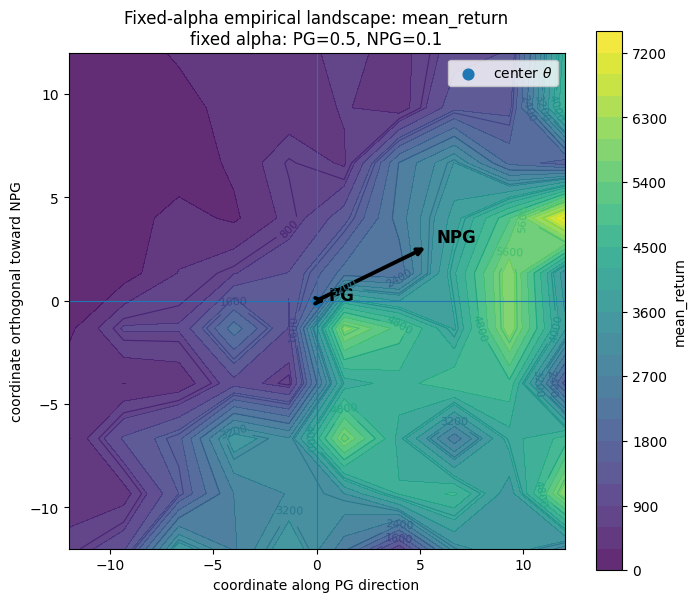

Center batch diagnostics
------------------------
eta_hat:        +19.917991
mean length:    78.04
mean lines:     22.97
n steps:        7804

Arrow diagnostics
-----------------
PG predicted improvement g^T delta:  +0.605675
NPG predicted improvement g^T delta: +5.933679

Empirical landscape diagnostics
-------------------------------
best mean_return:  +7273.333333
Evaluating 100 grid points.
Each grid point uses 6 episodes.
Total evaluation episodes: 600.
Arrow scaling: target-KL=0.01
Empirical contour evaluation finished in 60.0s.


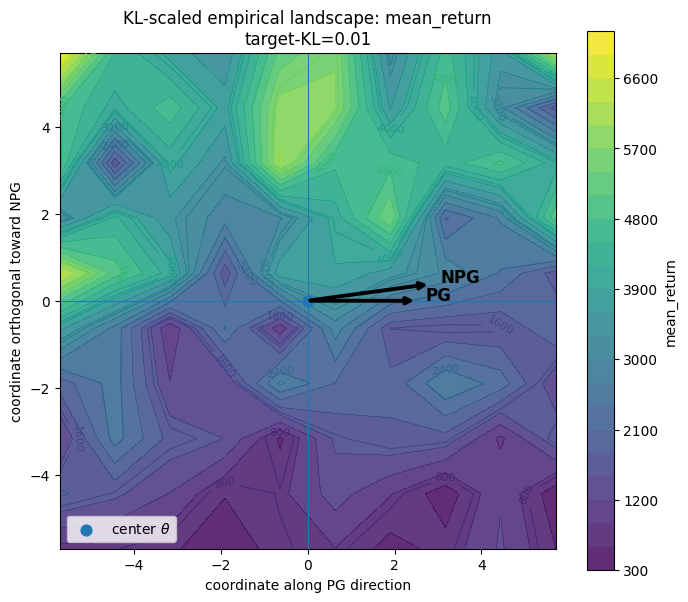

Center batch diagnostics
------------------------
eta_hat:        +22.155543
mean length:    139.64
mean lines:     47.69
n steps:        13964

Arrow diagnostics
-----------------
PG predicted improvement g^T delta:  +2.476525
NPG predicted improvement g^T delta: +2.781946

Empirical landscape diagnostics
-------------------------------
best mean_return:  +7103.333333


In [47]:
def orthonormal_basis_from(d1, d2, eps=1e-12):
    e1 = d1 / (np.linalg.norm(d1) + eps)
    u2 = d2 - e1 * float(e1 @ d2)
    if np.linalg.norm(u2) < eps:
        rr = np.random.default_rng(0).normal(size=d1.shape)
        u2 = rr - e1 * float(e1 @ rr)
    e2 = u2 / (np.linalg.norm(u2) + eps)
    return e1, e2

def evaluate_policy(theta, seed=0, n_episodes=10, max_steps=MAX_STEPS, temperature=1.0,
                    parallel_rollouts=PARALLEL_ROLLOUTS, n_jobs=N_JOBS):
    """
    Evaluate a fixed policy by running full episodes.

    The result is noisy because Tetris pieces are random. Increase n_episodes
    for a cleaner contour plot.
    """
    eval_rng = np.random.default_rng(seed)
    episodes = collect_episodes(theta, eval_rng, batch_episodes=n_episodes,
                                max_steps=max_steps, temperature=temperature,
                                keep_first_for_viz=False,
                                parallel_rollouts=parallel_rollouts,
                                n_jobs=n_jobs)

    total_returns = np.array([sum(ep.rewards) for ep in episodes], dtype=float)
    lengths = np.array([ep.length for ep in episodes], dtype=float)
    lines = np.array([ep.lines for ep in episodes], dtype=float)
    all_rewards = np.array([r for ep in episodes for r in ep.rewards], dtype=float)

    return dict(
        mean_return=float(total_returns.mean()),
        mean_reward_per_step=float(all_rewards.mean()) if len(all_rewards) else float("-inf"),
        mean_length=float(lengths.mean()),
        mean_lines=float(lines.mean()),
    )

def _evaluate_grid_point(theta, e1, e2, u, v, seed, eval_episodes, max_steps, temperature, metric):
    theta_test = theta + u * e1 + v * e2
    info = evaluate_policy(theta_test, seed=seed, n_episodes=eval_episodes,
                           max_steps=max_steps, temperature=temperature,
                           parallel_rollouts=False, n_jobs=1)
    return info[metric], info

def make_arrow_deltas(d_pg, d_npg, F, use_target_kl=True, target_kl=TARGET_KL,
                      alpha_pg=ALPHA_PG_RAW, alpha_npg=ALPHA_NPG_RAW):
    if use_target_kl:
        pg_delta = fisher_scaled_update(d_pg, F, target_kl)
        npg_delta = fisher_scaled_update(d_npg, F, target_kl)
        desc = f"target-KL={target_kl:g}"
    else:
        pg_delta = alpha_pg * d_pg
        npg_delta = alpha_npg * d_npg
        desc = f"fixed alpha: PG={alpha_pg:g}, NPG={alpha_npg:g}"
    return pg_delta, npg_delta, desc

def empirical_return_contour(theta, seed=999, damping=DAMPING, target_kl=TARGET_KL,
                             batch_episodes=BATCH_EPISODES, eval_episodes=6,
                             grid_size=10, radius_multiplier=2.0,
                             max_steps=MAX_STEPS, trace_decay=1.0,
                             temperature=1.0, metric="mean_return",
                             use_target_kl=True,
                             alpha_pg=ALPHA_PG_RAW, alpha_npg=ALPHA_NPG_RAW,
                             title_prefix="Empirical return landscape",
                             parallel_grid=True, n_jobs=N_JOBS):
    """
    Evaluate the empirical return landscape on the 2D plane spanned by PG and NPG.

    This is expensive: total evaluation episodes = grid_size^2 * eval_episodes.
    The evaluation itself is parallelized across grid points when possible.
    """
    local_rng = np.random.default_rng(seed)

    # Estimate local PG and NPG directions at the center theta.
    g, F, info = estimate_batch(theta, local_rng, batch_episodes=batch_episodes,
                                max_steps=max_steps, trace_decay=trace_decay,
                                temperature=temperature)

    d_pg = g
    d_npg = natural_direction(F, g, damping=damping)

    pg_delta, npg_delta, arrow_desc = make_arrow_deltas(
        d_pg, d_npg, F,
        use_target_kl=use_target_kl,
        target_kl=target_kl,
        alpha_pg=alpha_pg,
        alpha_npg=alpha_npg,
    )

    # Plane basis: e1 is PG, e2 is the component of NPG orthogonal to PG.
    e1, e2 = orthonormal_basis_from(d_pg, d_npg)

    pg_xy = np.array([float(pg_delta @ e1), float(pg_delta @ e2)])
    npg_xy = np.array([float(npg_delta @ e1), float(npg_delta @ e2)])

    arrow_scale = max(np.linalg.norm(pg_xy), np.linalg.norm(npg_xy), 1e-8)
    radius = radius_multiplier * arrow_scale

    us = np.linspace(-radius, radius, grid_size)
    vs = np.linspace(-radius, radius, grid_size)

    grid_points = []
    for i, v in enumerate(vs):
        for j, u in enumerate(us):
            point_seed = int(seed + 100000 + i * grid_size + j)
            grid_points.append((i, j, float(u), float(v), point_seed))

    print(f"Evaluating {len(grid_points)} grid points.")
    print(f"Each grid point uses {eval_episodes} episodes.")
    print(f"Total evaluation episodes: {len(grid_points) * eval_episodes}.")
    print(f"Arrow scaling: {arrow_desc}")

    start = time.time()

    use_parallel = parallel_grid and JOBLIB_AVAILABLE and n_jobs != 1 and len(grid_points) > 1
    if use_parallel:
        results = Parallel(n_jobs=n_jobs, prefer="processes")(
            delayed(_evaluate_grid_point)(
                theta, e1, e2, u, v, point_seed,
                eval_episodes, max_steps, temperature, metric
            )
            for (i, j, u, v, point_seed) in grid_points
        )
    else:
        results = [
            _evaluate_grid_point(theta, e1, e2, u, v, point_seed,
                                 eval_episodes, max_steps, temperature, metric)
            for (i, j, u, v, point_seed) in grid_points
        ]

    Z = np.zeros((grid_size, grid_size), dtype=float)
    full_info = [[None for _ in range(grid_size)] for _ in range(grid_size)]

    for (i, j, u, v, point_seed), (value, eval_info) in zip(grid_points, results):
        Z[i, j] = value
        full_info[i][j] = eval_info

    elapsed = time.time() - start
    print(f"Empirical contour evaluation finished in {elapsed:.1f}s.")

    U, V = np.meshgrid(us, vs)

    fig, ax = plt.subplots(figsize=(8, 7))
    cf = ax.contourf(U, V, Z, levels=25, alpha=0.85)
    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label(metric)

    cs = ax.contour(U, V, Z, levels=10, linewidths=0.8)
    ax.clabel(cs, inline=True, fontsize=8)

    ax.scatter([0.0], [0.0], s=60, label=r"center $\theta$")

    def draw_arrow(xy, label):
        ax.annotate(
            "",
            xy=(xy[0], xy[1]),
            xytext=(0.0, 0.0),
            arrowprops=dict(arrowstyle="->", linewidth=2.8),
        )
        ax.text(1.08 * xy[0], 1.08 * xy[1], label, fontsize=12, weight="bold")

    draw_arrow(pg_xy, "PG")
    draw_arrow(npg_xy, "NPG")

    ax.axhline(0.0, linewidth=0.8)
    ax.axvline(0.0, linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"coordinate along PG direction")
    ax.set_ylabel(r"coordinate orthogonal toward NPG")
    ax.set_title(f"{title_prefix}: {metric}\n{arrow_desc}")
    ax.legend(loc="best")
    plt.show()

    print("Center batch diagnostics")
    print("------------------------")
    print(f"eta_hat:        {info['eta_hat']:+.6f}")
    print(f"mean length:    {info['mean_length']:.2f}")
    print(f"mean lines:     {info['mean_lines']:.2f}")
    print(f"n steps:        {info['n_steps']}")
    print()
    print("Arrow diagnostics")
    print("-----------------")
    print(f"PG predicted improvement g^T delta:  {float(g @ pg_delta):+.6f}")
    print(f"NPG predicted improvement g^T delta: {float(g @ npg_delta):+.6f}")
    print()
    print("Empirical landscape diagnostics")
    print("-------------------------------")
    print(f"best {metric}:  {float(np.max(Z)):+.6f}")

    return dict(
        g=g,
        F=F,
        d_pg=d_pg,
        d_npg=d_npg,
        pg_delta=pg_delta,
        npg_delta=npg_delta,
        pg_xy=pg_xy,
        npg_xy=npg_xy,
        e1=e1,
        e2=e2,
        us=us,
        vs=vs,
        Z=Z,
        eval_info=full_info,
        center_info=info,
        use_target_kl=use_target_kl,
        arrow_desc=arrow_desc,
    )

# A modest default. Increase grid_size and eval_episodes for a cleaner but slower plot.
landscape_raw = empirical_return_contour(
    theta_npg_raw,
    seed=999,
    eval_episodes=6,
    grid_size=10,
    radius_multiplier=2.0,
    metric="mean_return",
    use_target_kl=False,
    alpha_pg=ALPHA_PG_RAW,
    alpha_npg=ALPHA_NPG_RAW,
    title_prefix="Fixed-alpha empirical landscape",
)

landscape_kl = empirical_return_contour(
    theta_npg_kl,
    seed=1001,
    eval_episodes=6,
    grid_size=10,
    radius_multiplier=2.0,
    metric="mean_return",
    use_target_kl=True,
    target_kl=TARGET_KL,
    title_prefix="KL-scaled empirical landscape",
)

## 8. Visualizing the greedy-action limit

For a softmax policy,

$$
\pi_{\theta+\alpha w}(a|s)
\propto
\exp(\theta^\top\phi_{s,a}+\alpha w^\top\phi_{s,a}).
$$

If $w=\widetilde{\nabla}\eta(\theta)$, then $w$ is also the compatible-function-approximation weight vector.

For a fixed state, we can compute

$$
f^\pi(s,a;w)=w^\top(\phi_{s,a}-\mathbb{E}_\pi[\phi_{s,\cdot}]).
$$

Since the expectation term does not depend on $a$, ranking by $f^\pi(s,a;w)$ is the same as ranking by $w^\top\phi_{s,a}$.

The visualization below shows that as $\alpha$ grows, the policy mass moves toward the actions that maximize $f^\pi(s,a;w)$.


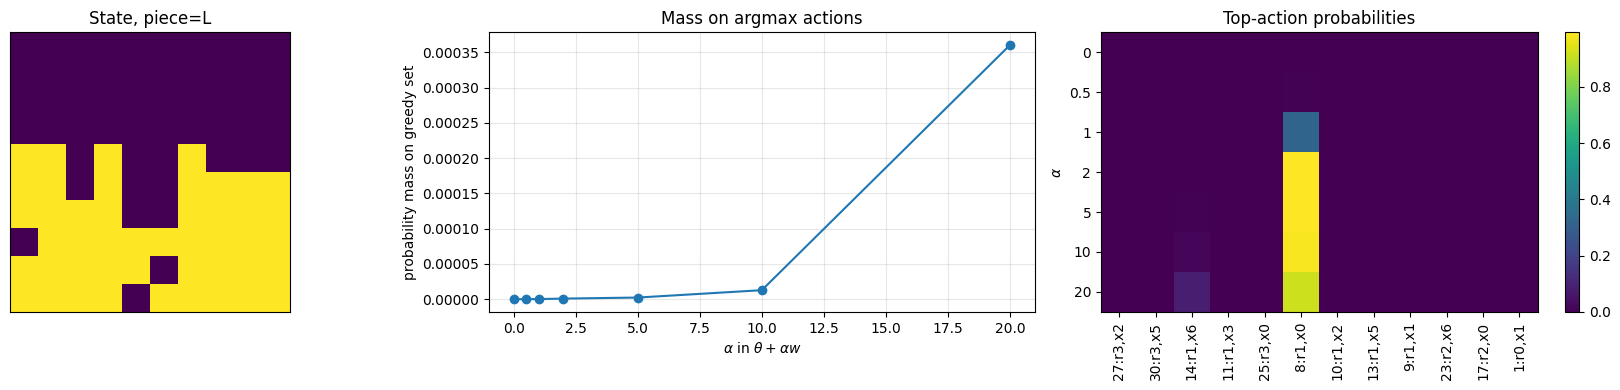

Top actions ranked by compatible approximation f(s,a;w):
 1. action 27 rot=3 x= 2 f=+9.7115 p0=0.0000
 2. action 30 rot=3 x= 5 f=+9.7009 p0=0.0000
 3. action 14 rot=1 x= 6 f=+9.5482 p0=0.0000
 4. action 11 rot=1 x= 3 f=+9.5003 p0=0.0000
 5. action 25 rot=3 x= 0 f=+9.4273 p0=0.0000
 6. action  8 rot=1 x= 0 f=+9.3704 p0=0.0001
 7. action 10 rot=1 x= 2 f=+9.3434 p0=0.0000
 8. action 13 rot=1 x= 5 f=+9.1586 p0=0.0000
 9. action  9 rot=1 x= 1 f=+9.1220 p0=0.0000
10. action 23 rot=2 x= 6 f=+6.2463 p0=0.0000


In [53]:
def find_interesting_state(theta, seed=1234, burn_in=30):
    local_rng = np.random.default_rng(seed)
    board = empty_board()
    saved = None
    for t in range(burn_in):
        piece_id = int(local_rng.integers(len(PIECE_NAMES)))
        actions = attach_features(legal_afterstates(board, piece_id))
        if len(actions) == 0:
            board = empty_board()
            continue
        if len(actions) >= 6:
            saved = dict(board=board.copy(), piece_id=piece_id, actions=actions)
        idx, probs, score, phis, logits = sample_policy_action(theta, actions, local_rng)
        board = actions[idx]["board"]
    if saved is None:
        # fallback empty board
        piece_id = int(local_rng.integers(len(PIECE_NAMES)))
        saved = dict(board=empty_board(), piece_id=piece_id,
                     actions=attach_features(legal_afterstates(empty_board(), piece_id)))
    return saved

def compute_current_npg(theta, seed=555):
    local_rng = np.random.default_rng(seed)
    g, F, info = estimate_batch(theta, local_rng, batch_episodes=BATCH_EPISODES, max_steps=MAX_STEPS)
    w = natural_direction(F, g, damping=DAMPING)
    return w, g, F, info

def plot_greedy_limit(theta, state, w, alphas=(0, 0.5, 1, 2, 5, 10, 20), top_k=12):
    actions = state["actions"]
    phis = np.stack([a["phi"] for a in actions], axis=0)
    probs0, expected_phi, logits0 = policy_distribution(theta, phis)
    psi = phis - expected_phi
    fvals = psi @ w

    order = np.argsort(-fvals)
    greedy_val = fvals[order[0]]
    greedy_set = np.where(np.isclose(fvals, greedy_val, atol=1e-8))[0]

    top = order[:min(top_k, len(order))]
    labels = [f"{i}:r{actions[i]['rot_id']},x{actions[i]['x']}" for i in top]

    mass_on_greedy = []
    prob_matrix = []
    for a in alphas:
        probs, _, _ = policy_distribution(theta + a*w, phis)
        mass_on_greedy.append(probs[greedy_set].sum())
        prob_matrix.append(probs[top])
    prob_matrix = np.array(prob_matrix)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    render_board(state["board"], ax=axes[0], title=f"State, piece={PIECE_NAMES[state['piece_id']]}")

    axes[1].plot(alphas, mass_on_greedy, marker="o")
    axes[1].set_xlabel(r"$\alpha$ in $\theta+\alpha w$")
    axes[1].set_ylabel("probability mass on greedy set")
    axes[1].set_title("Mass on argmax actions")
    axes[1].grid(True, alpha=0.3)

    im = axes[2].imshow(prob_matrix, aspect="auto", interpolation="nearest")
    axes[2].set_yticks(range(len(alphas)))
    axes[2].set_yticklabels([str(a) for a in alphas])
    axes[2].set_xticks(range(len(top)))
    axes[2].set_xticklabels(labels, rotation=90)
    axes[2].set_ylabel(r"$\alpha$")
    axes[2].set_title("Top-action probabilities")
    fig.colorbar(im, ax=axes[2])

    plt.tight_layout()
    plt.show()

    print("Top actions ranked by compatible approximation f(s,a;w):")
    for rank, i in enumerate(order[:10]):
        print(f"{rank+1:2d}. action {i:2d} rot={actions[i]['rot_id']} x={actions[i]['x']:2d} "
              f"f={fvals[i]:+.4f} p0={probs0[i]:.4f}")

w_npg, g_for_w, F_for_w, info_for_w = compute_current_npg(theta_npg)
state = find_interesting_state(theta_npg)
plot_greedy_limit(theta_npg, state, w_npg)
